# Processed Data EDA Summary

This notebook replicates `src/eda_processed.py` in an interactive form.

In [1]:
from pathlib import Path
import csv
import json
ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / 'data' / 'processed'
OUT_DIR = ROOT / 'data' / 'eda' / 'processed'


In [2]:
def _count_csv(path):
    with path.open('r', encoding='utf-8', errors='replace', newline='') as f:
        reader = csv.reader(f)
        header = next(reader, [])
        rows = sum(1 for _ in reader)
    return rows, header

def _count_jsonl(path):
    rows = 0
    keys = []
    with path.open('r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows += 1
            if rows == 1:
                try:
                    obj = json.loads(line)
                    if isinstance(obj, dict):
                        keys = list(obj.keys())
                except json.JSONDecodeError:
                    pass
    return rows, keys

def _count_parquet(path):
    try:
        import pyarrow.parquet as pq
    except Exception:
        return 0, []
    pf = pq.ParquetFile(path)
    return pf.metadata.num_rows, pf.schema.names

def _file_summary(path):
    info = {
        'file': str(path.relative_to(PROCESSED_DIR)),
        'bytes': path.stat().st_size,
        'rows': 0,
        'columns': [],
        'type': path.suffix.lower().lstrip('.'),
    }
    suffix = path.suffix.lower()
    if suffix == '.csv':
        rows, cols = _count_csv(path)
        info['rows'] = rows
        info['columns'] = cols
    elif suffix == '.jsonl':
        rows, cols = _count_jsonl(path)
        info['rows'] = rows
        info['columns'] = cols
    elif suffix == '.parquet':
        rows, cols = _count_parquet(path)
        info['rows'] = rows
        info['columns'] = cols
    return info


In [3]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
if not PROCESSED_DIR.exists():
    raise FileNotFoundError(f'Missing processed dir: {PROCESSED_DIR}')

files = [p for p in PROCESSED_DIR.rglob('*') if p.is_file()]
file_rows = []
for p in files:
    info = _file_summary(p)
    file_rows.append(info)

with (OUT_DIR / 'processed_file_summary.json').open('w', encoding='utf-8') as f:
    json.dump(file_rows, f, indent=2)

with (OUT_DIR / 'processed_file_summary.csv').open('w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(
        f,
        fieldnames=['file', 'bytes', 'rows', 'columns', 'type'],
    )
    writer.writeheader()
    for row in file_rows:
        out = dict(row)
        if isinstance(out.get('columns'), list):
            out['columns'] = ','.join(out['columns'])
        writer.writerow(out)

print(f'Wrote processed EDA summaries to {OUT_DIR}')


Wrote processed EDA summaries to C:\Users\Ling Jun\Desktop\PSB\AI-ethics\data\eda\processed


## Visualizations

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_theme(style='whitegrid')

# Load a processed dataset CSV (pick one dataset folder)
# Update dataset_name if needed
dataset_name = 'ethics'
processed_csv = PROCESSED_DIR / dataset_name / f'{dataset_name}.csv'

if not processed_csv.exists():
    raise FileNotFoundError(f'Processed CSV not found: {processed_csv}')

df = pd.read_csv(processed_csv)
df['text'] = df.get('text', '').fillna('').astype(str)
df['label'] = df.get('label', '').fillna('').astype(str)

# Basic derived columns
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()

print(df.shape)
df.head()


(135411, 9)


,text,label,dataset,task,split,source_file,metadata,char_len,word_len
0,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{""category"": ""commonsense"", ""text_field"": """", ...",0,0
1,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{""category"": ""commonsense"", ""text_field"": """", ...",0,0
2,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{""category"": ""commonsense"", ""text_field"": """", ...",0,0
3,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{""category"": ""commonsense"", ""text_field"": """", ...",0,0
4,,,ethics,cm,ambig,commonsense\cm_ambig.csv,"{""category"": ""commonsense"", ""text_field"": """", ...",0,0


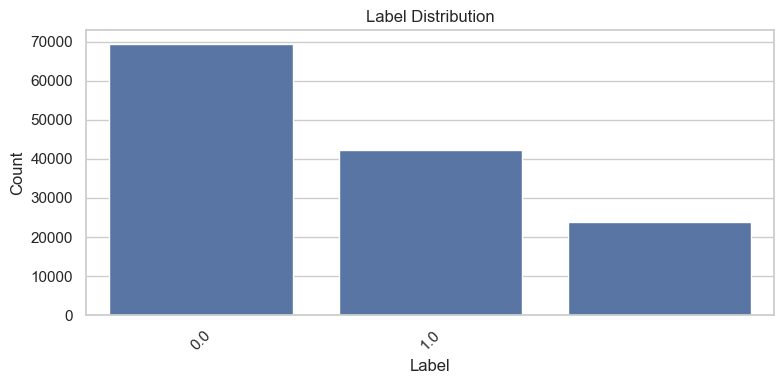

In [5]:
# 1) Label distribution
label_counts = df['label'].value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


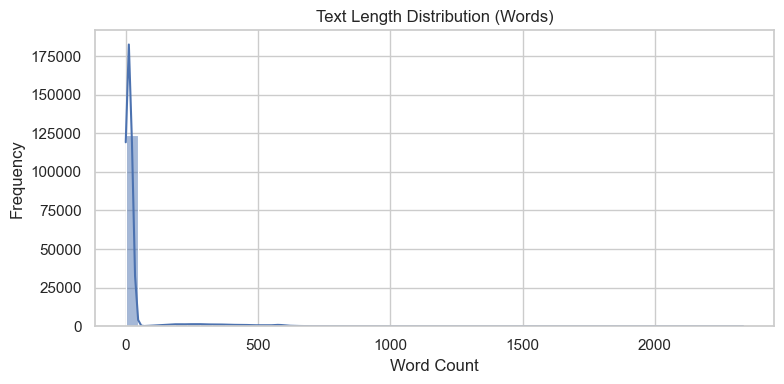

In [6]:
# 2) Text length distribution (words)
plt.figure(figsize=(8, 4))
sns.histplot(df['word_len'], bins=50, kde=True)
plt.title('Text Length Distribution (Words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


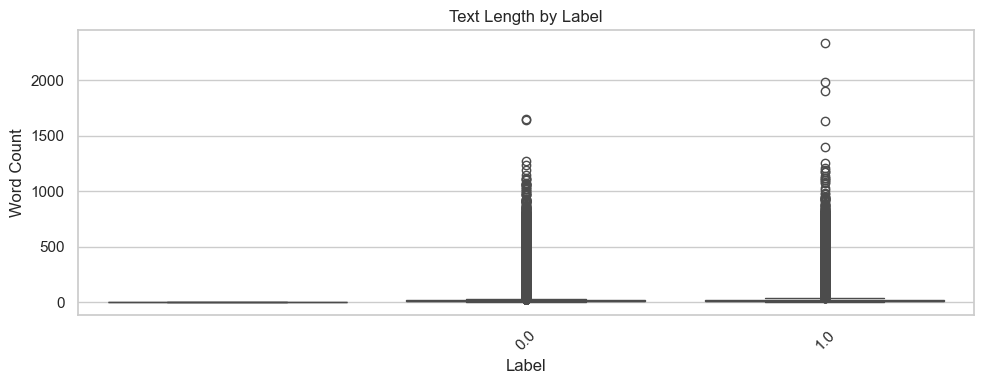

In [7]:
# 3) Text length by label
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='label', y='word_len')
plt.title('Text Length by Label')
plt.xlabel('Label')
plt.ylabel('Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


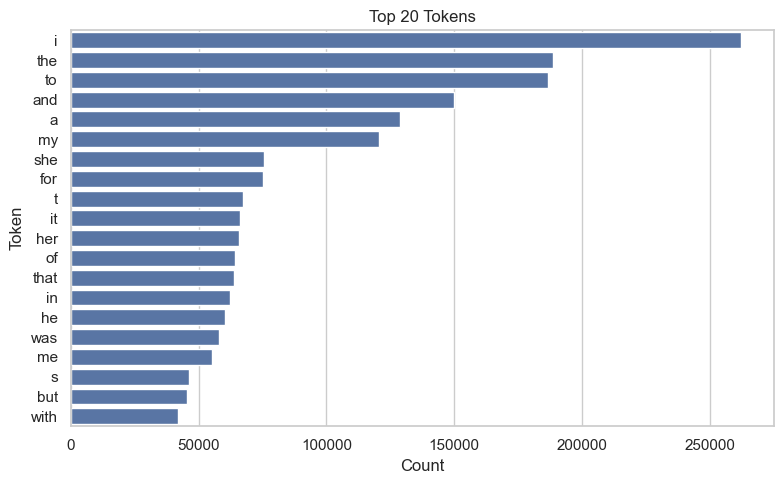

In [8]:
# 4) Top tokens overall (basic tokenization)
tokens = re.findall(r'\b\w+\b', ' '.join(df['text'].tolist()).lower())
token_counts = Counter(tokens)
top_tokens = token_counts.most_common(20)

tok_df = pd.DataFrame(top_tokens, columns=['token', 'count'])
plt.figure(figsize=(8, 5))
sns.barplot(data=tok_df, x='count', y='token')
plt.title('Top 20 Tokens')
plt.xlabel('Count')
plt.ylabel('Token')
plt.tight_layout()
plt.show()
